## nb30 — Citation & Publication Lift by CORE Tier (RQ3)

Are the lift effects concentrated at A* venues, or do they hold across tiers?

**Data:** `author_lift.csv` + `conference_core_ranks.csv`
**Design:** A* vs. non-A* (binary collapse — no A-tier conferences in sample)

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy import stats
from pathlib import Path

MATCH   = Path('..') / 'data' / 'matched'
FIG_DIR = Path('..') / 'data' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

In [10]:
lift = pd.read_csv(MATCH / 'author_lift.csv')
core = pd.read_csv(MATCH / 'conference_core_ranks.csv')

lift['conference'] = lift['conference'].str.strip().str.upper()
core['conference'] = core['conference'].str.strip().str.upper()

if 'core_rank' in lift.columns:
    lift = lift.drop(columns='core_rank')

df = lift.merge(core, on='conference', how='left')

# Binary collapse: A* vs non-A*
df['tier'] = df['core_rank'].apply(lambda x: 'A*' if x == 'A*' else 'Non-A*')

# Award authors only, cap outliers
award = df[(df['treatment'] == 1) & (df['lift_citations'] <= 20)].copy()

print(award['tier'].value_counts())
print(award.groupby('tier')[['lift_citations', 'lift_works']].median().round(3))

tier
A*        276
Non-A*    121
Name: count, dtype: int64
        lift_citations  lift_works
tier                              
A*               1.476       1.581
Non-A*           1.273       1.375


In [11]:
astar   = award[award['tier'] == 'A*']
nonastar = award[award['tier'] == 'Non-A*']

mw_cit = stats.mannwhitneyu(astar['lift_citations'].dropna(), nonastar['lift_citations'].dropna(), alternative='two-sided')
mw_wrk = stats.mannwhitneyu(astar['lift_works'].dropna(),     nonastar['lift_works'].dropna(),     alternative='two-sided')

print(f'Citation lift  — Mann-Whitney U={mw_cit.statistic:.0f}, p={mw_cit.pvalue:.4f}')
print(f'Publication lift — Mann-Whitney U={mw_wrk.statistic:.0f}, p={mw_wrk.pvalue:.4f}')

Citation lift  — Mann-Whitney U=17704, p=0.3396
Publication lift — Mann-Whitney U=17752, p=0.3167


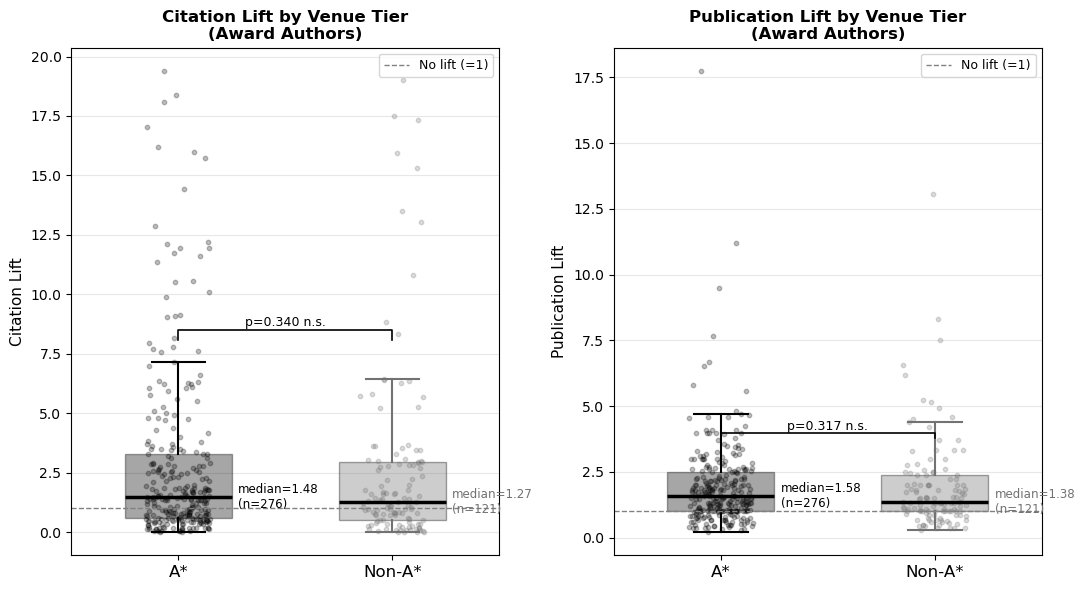

Saved.


In [13]:
COLORS = {'A*': "#000000", 'Non-A*': "#727272"}
tier_order = ['A*', 'Non-A*']
p_vals = {'lift_citations': mw_cit.pvalue, 'lift_works': mw_wrk.pvalue}

fig, axes = plt.subplots(1, 2, figsize=(11, 6))

for ax, metric, label in zip(axes, ['lift_citations', 'lift_works'], ['Citation Lift', 'Publication Lift']):
    for pos, tier in enumerate(tier_order, 1):
        data = award[award['tier'] == tier][metric].dropna()
        ax.boxplot(
            data, positions=[pos], widths=0.5, patch_artist=True,
            boxprops=dict(facecolor=COLORS[tier], alpha=0.35),
            medianprops=dict(color='black', linewidth=2.5),
            whiskerprops=dict(color=COLORS[tier], linewidth=1.5),
            capprops=dict(color=COLORS[tier], linewidth=1.5),
            flierprops=dict(marker='', linestyle='none')
        )
        jitter = np.random.uniform(-0.15, 0.15, size=len(data))
        ax.scatter(pos + jitter, data, alpha=0.25, s=10, color=COLORS[tier], zorder=2)
        med = data.median()
        ax.annotate(f'median={med:.2f}\n(n={len(data)})', xy=(pos, med),
                    xytext=(pos + 0.28, med), fontsize=8.5, color=COLORS[tier], va='center')

    # significance bracket
    p = p_vals[metric]
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'n.s.'))
    y_top = award[metric].quantile(0.92)
    ax.plot([1, 1, 2, 2], [y_top*0.95, y_top, y_top, y_top*0.95], color='black', lw=1.2)
    ax.text(1.5, y_top * 1.02, f'p={p:.3f} {sig}', ha='center', fontsize=9)

    ax.axhline(1.0, color='gray', linestyle='dashed', linewidth=1, label='No lift (=1)')
    ax.set_xticks([1, 2])
    ax.set_xticklabels(tier_order, fontsize=12)
    ax.set_ylabel(label, fontsize=11)
    ax.set_title(f'{label} by Venue Tier\n(Award Authors)', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / '30_lift_by_core_tier.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved.')